# Question 4

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.signal import find_peaks

## PART 1
Use the flat-field image to determine the tramline positions as a function of dispersion
pixel and fit an appropriate smooth function. Briefly explain your approach and plot the
flat with your fitted tramlines overlaid.
Hints: Each row of the image is a cross-dispersion profile. No particular fitting method
or polynomial order is required; motivate and use a reasonable method

## PART 2
Sum the counts between your tramlines to extract the flat-field and Moon spectra. Divide
Moon by flat and plot the result as a function of dispersion pixel. 

⋆ Identify and indicate the pixels corresponding to the CaII lines at 8498, 8542, and 8662˚A

Hint: If you got stuck with the previous task, sum the full images across the cross
dispersion direction with np.sum(data, axis=1). This would not work with the un
edited spectrum images, because the other orders would still be present (hence task 1)!

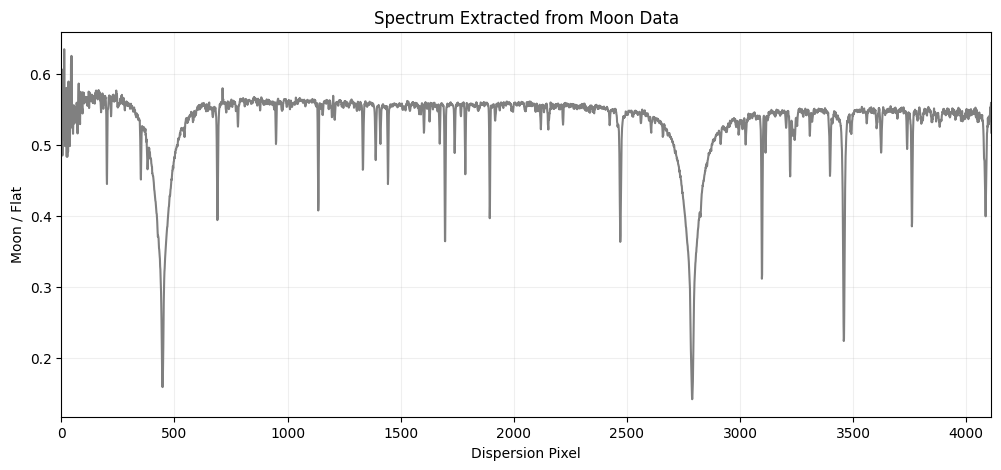

In [12]:
# Initialise data 
flat = fits.getdata("data/flat.fits")
moon = fits.getdata("data/moon.fits")
# Axis=1 sums across the horizontal axis (cross-dispersion)
flat_spectrum = np.sum(flat, axis=1)
moon_spectrum = np.sum(moon, axis=1)

# Dispersion pixel numbers
dispersion_pixel = np.arange(len(flat_spectrum))

# Divide moon spectrum by flat spectrum
moon_div_flat = moon_spectrum/flat_spectrum

# Plot
plt.figure(figsize=(12, 5))
plt.plot(dispersion_pixel, moon_div_flat, color="grey")
plt.xlabel("Dispersion Pixel")
plt.ylabel("Moon / Flat")
plt.xlim(0, len(dispersion_pixel) - 1)
plt.grid(alpha=0.2)
plt.title("Spectrum Extracted from Moon Data")

plt.savefig("figures/moon_spectrum.png")
plt.show()

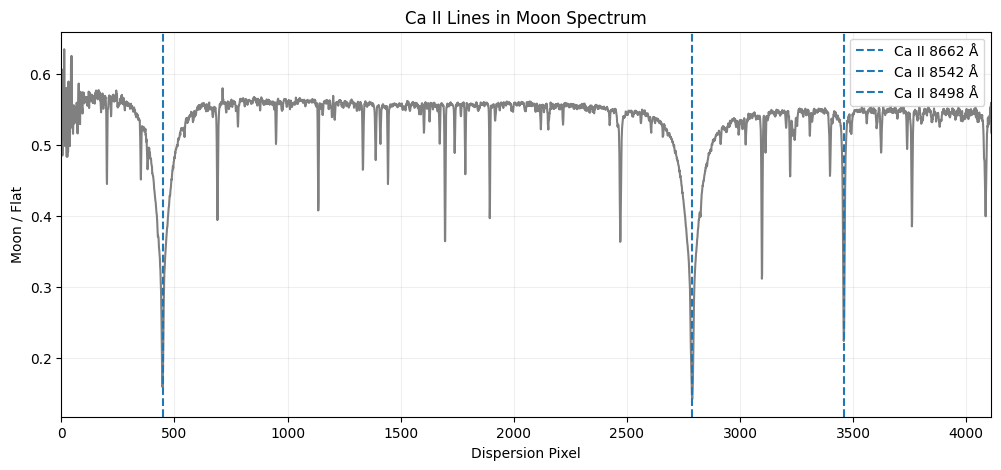

Ca II 8662 Å: pixel 448
Ca II 8542 Å: pixel 2789
Ca II 8498 Å: pixel 3459


In [13]:
# Find deepest peaks in the spectrum using scipy find_peaks
line_pixels, _ = find_peaks(-moon_div_flat, prominence=0.02, distance=100)

# Select the three deepest lines (the three Ca II lines)
deepest = np.argsort(moon_div_flat[line_pixels])[:3]
Ca_pixels = np.sort(line_pixels[deepest])

# Plot spectrum
plt.figure(figsize=(12, 5))
plt.plot(dispersion_pixel, moon_div_flat, color="grey")

Ca_wavelengths = [8662, 8542, 8498]
# Mark Ca II lines
for wavelength, pixel in zip(Ca_wavelengths, Ca_pixels):
    plt.axvline(pixel, linestyle="--", label=f"Ca II {wavelength} Å")

plt.xlabel("Dispersion Pixel")
plt.ylabel("Moon / Flat")
plt.xlim(0, len(dispersion_pixel) - 1)
plt.title("Ca II Lines in Moon Spectrum")
plt.legend()
plt.grid(alpha=0.2)

plt.savefig("figures/moon_spectrum_Ca_lines.png")
plt.show()

# Print pixels corresponding to Ca lines
for wavelength, pixel in zip(Ca_wavelengths, Ca_pixels):
    print(f"Ca II {wavelength} Å: pixel {pixel}")